<a href="https://colab.research.google.com/github/kishoredage/letter_recognizer/blob/main/RF_campx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [3]:
x,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [4]:
df = pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.668649,-1.646931,0.007096,2.481606,0.666939,0
1,1.496512,-0.698643,0.620844,0.498962,-0.561993,0
2,0.961586,-0.455709,1.080028,1.216667,-2.019020,0
3,0.431651,-0.666030,-0.615089,2.319547,0.715994,0
4,0.950284,1.410907,-1.135206,-1.346643,-4.241320,1


In [5]:
# functions for row sampling
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [6]:
#function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]-1))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [7]:
# function for combined sampling
def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [8]:
df1 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_2383/969773875.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [9]:
df2 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_2383/969773875.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [10]:
df3 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_2383/969773875.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [11]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col4', 'target'], dtype='object')
Index(['col5', 'col1', 'target'], dtype='object')
Index(['col2', 'col1', 'target'], dtype='object')


In [12]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [13]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [1]:
from sklearn.tree import plot_tree

[Text(0.5555555555555556, 0.9285714285714286, 'x[0] <= 0.956\ngini = 0.461\nsamples = 50\nvalue = [18, 32]'),
 Text(0.4444444444444444, 0.7857142857142857, 'x[0] <= -0.344\ngini = 0.295\nsamples = 39\nvalue = [7, 32]'),
 Text(0.5, 0.8571428571428572, 'True  '),
 Text(0.2222222222222222, 0.6428571428571429, 'x[0] <= -0.529\ngini = 0.077\nsamples = 25\nvalue = [1, 24]'),
 Text(0.1111111111111111, 0.5, 'gini = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.3333333333333333, 0.5, 'x[1] <= 1.186\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.2222222222222222, 0.35714285714285715, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.4444444444444444, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.6428571428571429, 'x[1] <= 0.374\ngini = 0.49\nsamples = 14\nvalue = [6, 8]'),
 Text(0.5555555555555556, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.7777777777777778, 0.5, 'x[1] <= 3.031\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Tex

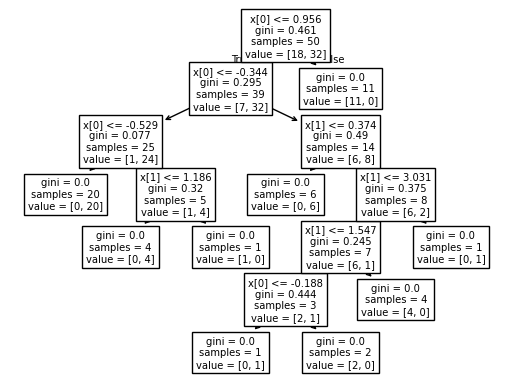

In [14]:
plot_tree(clf1)

[Text(0.38461538461538464, 0.9166666666666666, 'x[1] <= -0.002\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.15384615384615385, 0.75, 'x[0] <= 1.589\ngini = 0.219\nsamples = 24\nvalue = [3, 21]'),
 Text(0.2692307692307693, 0.8333333333333333, 'True  '),
 Text(0.07692307692307693, 0.5833333333333334, 'gini = 0.0\nsamples = 21\nvalue = [0, 21]'),
 Text(0.23076923076923078, 0.5833333333333334, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6153846153846154, 0.75, 'x[0] <= -1.506\ngini = 0.26\nsamples = 26\nvalue = [22, 4]'),
 Text(0.5, 0.8333333333333333, '  False'),
 Text(0.38461538461538464, 0.5833333333333334, 'x[0] <= -2.339\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.3076923076923077, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[0] <= -1.903\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5384615384615384, 0.25, 

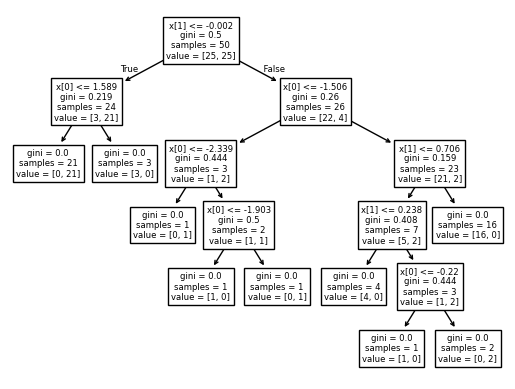

In [15]:
plot_tree(clf2)

[Text(0.5, 0.875, 'x[1] <= 0.064\ngini = 0.403\nsamples = 50\nvalue = [36.0, 14.0]'),
 Text(0.2, 0.625, 'x[0] <= -1.347\ngini = 0.305\nsamples = 16\nvalue = [3, 13]'),
 Text(0.35, 0.75, 'True  '),
 Text(0.1, 0.375, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.3, 0.375, 'x[0] <= -0.556\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.625, 'x[1] <= 0.357\ngini = 0.057\nsamples = 34\nvalue = [33, 1]'),
 Text(0.65, 0.75, '  False'),
 Text(0.7, 0.375, 'x[1] <= 0.243\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.9, 0.375, 'gini = 0.0\nsamples = 31\nvalue = [31, 0]')]

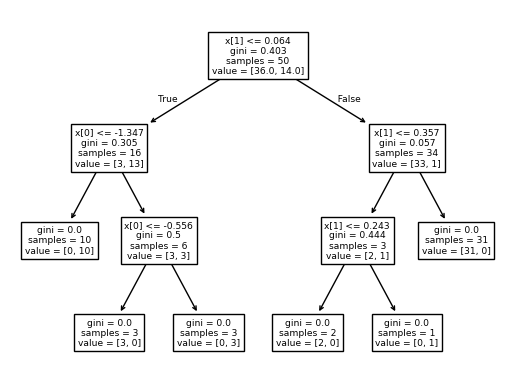

In [16]:
plot_tree(clf3)

In [19]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [20]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [21]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [22]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
40,-2.491742,-3.120577,0.652533,0.736249,-0.984056,1
19,1.590394,-0.562543,1.628681,-0.897634,1.708704,0
12,-2.567882,-2.215549,-1.341099,2.849798,1.051728,1
36,1.586329,-2.003641,1.916299,0.033139,1.982886,0
2,0.961586,-0.455709,1.080028,1.216667,-2.019020,0
49,0.279241,-0.653455,-2.155335,1.540178,-0.036705,1
62,0.818748,-0.119916,0.534987,0.469926,-0.526073,0
68,-3.451845,-2.592635,0.083746,1.421835,-0.915183,1
48,1.337158,-1.869053,1.051932,0.303520,2.634256,0
79,0.837677,-0.823930,0.701507,2.566847,-0.614745,0
